# Caracterización visual del catálogo — StreamView Analytics

Este notebook responde las preguntas de caracterización solicitadas para EP1 usando exclusivamente las vistas analíticas aprobadas en las Etapas 1 a 3.

## 1. Objetivo

Describir la composición del catálogo por tipo de contenido, géneros, países e idiomas. Esta etapa no analiza popularity, evolución temporal, variables financieras, ROI, directores ni cast.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

working_directory = Path.cwd().resolve()
PROJECT_ROOT = working_directory if (working_directory / 'data' / 'raw').exists() else working_directory.parent
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
MOVIES_PATH = DATA_RAW / 'netflix_movies_detailed_up_to_2025.csv'
TV_SHOWS_PATH = DATA_RAW / 'netflix_tv_shows_detailed_up_to_2025.csv'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_cleaning import build_catalog_views

views = build_catalog_views(MOVIES_PATH, TV_SHOWS_PATH)
catalogo_general = views['catalogo_general']
catalogo_generos = views['catalogo_generos']
catalogo_paises = views['catalogo_paises']

print(f'Vistas reconstruidas en memoria: {len(catalogo_general):,} contenidos únicos.')
print(f'Figuras finales: {FIGURES_DIR}')

Vistas reconstruidas en memoria: 31,991 contenidos únicos.
Figuras finales: C:\Users\cesar\OneDrive\Desktop\DuocUC\3erYear\visualizacionDatos\streamview-analytics-visualizacion-datos\outputs\figures


## 2. Fuentes analíticas y cobertura

- Movies vs TV Shows e idiomas: catalogo_general.
- Géneros: catalogo_generos, con una relación única por content_id y genre.
- Países: catalogo_paises, con una relación única por content_id y country.

Los porcentajes de cobertura se calculan en esta ejecución y los rankings excluyen valores desconocidos, sin convertirlos en una categoría de negocio.

In [2]:
coverage_summary = pd.DataFrame([
    {'variable': 'genres', 'entidades_con_informacion': catalogo_generos['content_id'].nunique()},
    {'variable': 'country', 'entidades_con_informacion': catalogo_paises['content_id'].nunique()},
    {'variable': 'language', 'entidades_con_informacion': catalogo_general['language'].notna().sum()},
])
coverage_summary['entidades_totales'] = len(catalogo_general)
coverage_summary['cobertura_pct'] = coverage_summary['entidades_con_informacion'] / coverage_summary['entidades_totales'] * 100
display(coverage_summary)
coverage_by_variable = coverage_summary.set_index('variable')['cobertura_pct'].to_dict()

,variable,entidades_con_informacion,entidades_totales,cobertura_pct
0,genres,30912,31991,96.627176
1,country,29730,31991,92.932387
2,language,31991,31991,100.000000


## 3. Distribución Movies vs TV Shows

**Pregunta de negocio:** ¿Cómo se distribuye el catálogo entre películas y series?

**Métrica:** cantidad y porcentaje de contenidos únicos por type.

**Visualización:** barras simples, adecuadas para comparar dos categorías.

,type,cantidad,porcentaje
0,Movie,16000,50.014066
1,TV Show,15991,49.985934


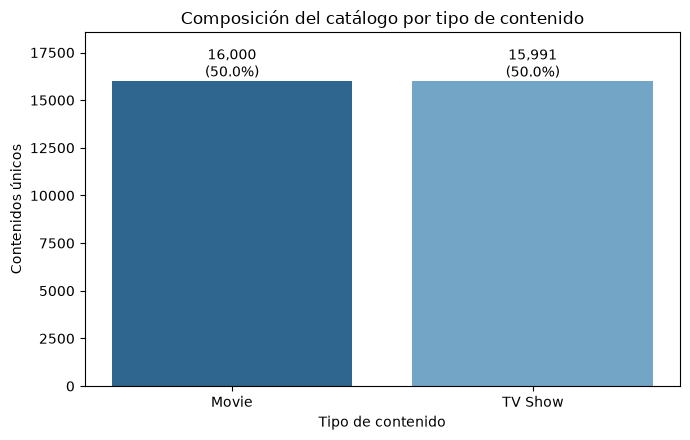

### Hallazgo

Movie concentra 16,000 contenidos (50.0% del catalogo), frente a 15,991 de TV Show.

### Interpretación

La composición es casi equilibrada, con una diferencia de 9 contenidos entre ambos tipos.

### Implicación

La oferta presenta una presencia prácticamente equilibrada de películas y series, por lo que ambos formatos tienen un peso similar en la composición del catálogo.

In [3]:
type_summary = catalogo_general.groupby('type', as_index=False)['content_id'].nunique().rename(columns={'content_id': 'cantidad'})
type_summary['porcentaje'] = type_summary['cantidad'] / type_summary['cantidad'].sum() * 100
type_summary = type_summary.sort_values('cantidad', ascending=False).reset_index(drop=True)
display(type_summary)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(type_summary['type'], type_summary['cantidad'], color=['#2F6690', '#73A5C6'])
ax.set_title('Composición del catálogo por tipo de contenido')
ax.set_xlabel('Tipo de contenido')
ax.set_ylabel('Contenidos únicos')
ax.set_ylim(0, type_summary['cantidad'].max() * 1.16)
for bar, row in zip(bars, type_summary.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{row.cantidad:,}\n({row.porcentaje:.1f}%)', ha='center', va='bottom')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'peliculas_vs_series.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

principal_tipo, principal_cantidad, principal_porcentaje = type_summary.iloc[0][['type', 'cantidad', 'porcentaje']]
segundo_tipo, segunda_cantidad = type_summary.iloc[1][['type', 'cantidad']]
display(Markdown(f'''### Hallazgo

{principal_tipo} concentra {principal_cantidad:,} contenidos ({principal_porcentaje:.1f}% del catalogo), frente a {segunda_cantidad:,} de {segundo_tipo}.

### Interpretación

La composición es casi equilibrada, con una diferencia de {principal_cantidad - segunda_cantidad:,} contenidos entre ambos tipos.

### Implicación

La oferta presenta una presencia prácticamente equilibrada de películas y series, por lo que ambos formatos tienen un peso similar en la composición del catálogo.'''))

## 4. Géneros predominantes

**Pregunta de negocio:** ¿Qué géneros predominan en el catálogo?

**Métrica:** contenidos únicos asociados a cada género y porcentaje sobre las entidades con información de género.

**Visualización:** ranking horizontal de los 10 géneros con mayor presencia para mantener legibilidad.

,genre,cantidad,porcentaje
0,Drama,14769,47.777562
1,Comedy,9105,29.454581
2,Animation,4069,13.163173
3,Thriller,3769,12.192676
4,Action,3239,10.478131
5,Crime,3203,10.361672
6,Family,3014,9.750259
7,Mystery,2574,8.326863
8,Romance,2571,8.317158
9,Horror,2425,7.844850


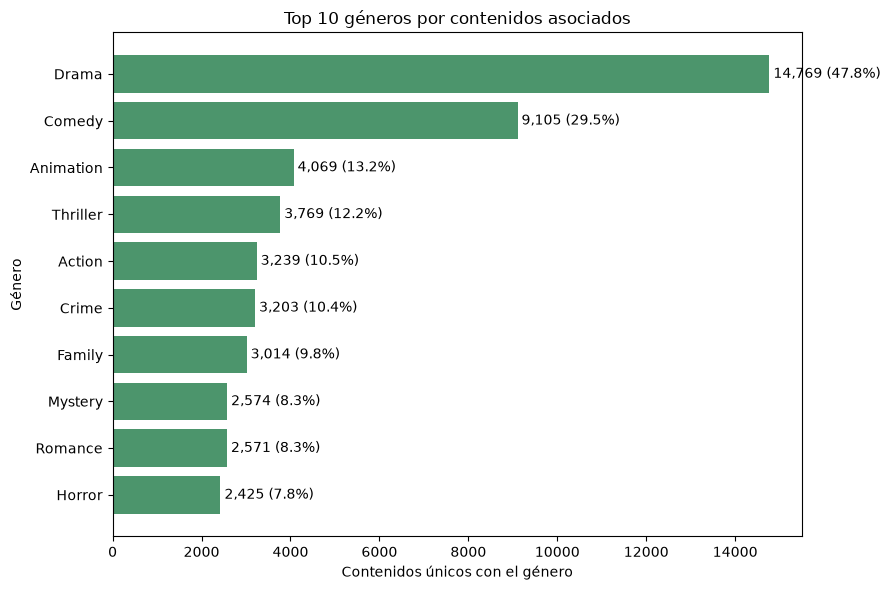

### Hallazgo

Drama es el género con mayor presencia, asociado a 14,769 contenidos; supera a Comedy por 5,664 asociaciones.

### Interpretación

El ranking describe asociaciones de género y no categorías excluyentes: un mismo contenido puede aportar a varios géneros. La cobertura observada es 96.627%.

### Implicación

La concentración de los géneros superiores puede considerarse al revisar diversidad de catálogo, sin inferir demanda o rentabilidad.

In [4]:
genre_denominator = catalogo_generos['content_id'].nunique()
genre_top10 = catalogo_generos.groupby('genre', as_index=False)['content_id'].nunique().rename(columns={'content_id': 'cantidad'})
genre_top10['porcentaje'] = genre_top10['cantidad'] / genre_denominator * 100
genre_top10 = genre_top10.nlargest(10, 'cantidad').reset_index(drop=True)
display(genre_top10)

plot_data = genre_top10.sort_values('cantidad')
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(plot_data['genre'], plot_data['cantidad'], color='#4C956C')
ax.set_title('Top 10 géneros por contenidos asociados')
ax.set_xlabel('Contenidos únicos con el género')
ax.set_ylabel('Género')
for bar, row in zip(bars, plot_data.itertuples()):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f' {row.cantidad:,} ({row.porcentaje:.1f}%)', va='center')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'generos_predominantes.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

genre_first, genre_first_count = genre_top10.iloc[0][['genre', 'cantidad']]
genre_second, genre_second_count = genre_top10.iloc[1][['genre', 'cantidad']]
display(Markdown(f'''### Hallazgo

{genre_first} es el género con mayor presencia, asociado a {genre_first_count:,} contenidos; supera a {genre_second} por {genre_first_count - genre_second_count:,} asociaciones.

### Interpretación

El ranking describe asociaciones de género y no categorías excluyentes: un mismo contenido puede aportar a varios géneros. La cobertura observada es {coverage_by_variable['genres']:.3f}%.

### Implicación

La concentración de los géneros superiores puede considerarse al revisar diversidad de catálogo, sin inferir demanda o rentabilidad.'''))

## 5. Distribución geográfica

**Pregunta de negocio:** ¿Qué países tienen mayor representación en el catálogo?

**Métrica:** contenidos únicos asociados a cada país y porcentaje sobre las entidades con información de país.

**Visualización:** ranking horizontal de los 10 países principales. Un contenido puede asociarse a varios países, por lo que los porcentajes no suman 100 %.

,country,cantidad,porcentaje
0,United States of America,10955,36.848301
1,Japan,2869,9.650185
2,United Kingdom,2608,8.772284
3,China,2399,8.069290
4,South Korea,2174,7.312479
5,France,2108,7.090481
6,Canada,1715,5.768584
7,Germany,1160,3.901783
8,India,912,3.067608
9,Spain,822,2.764884


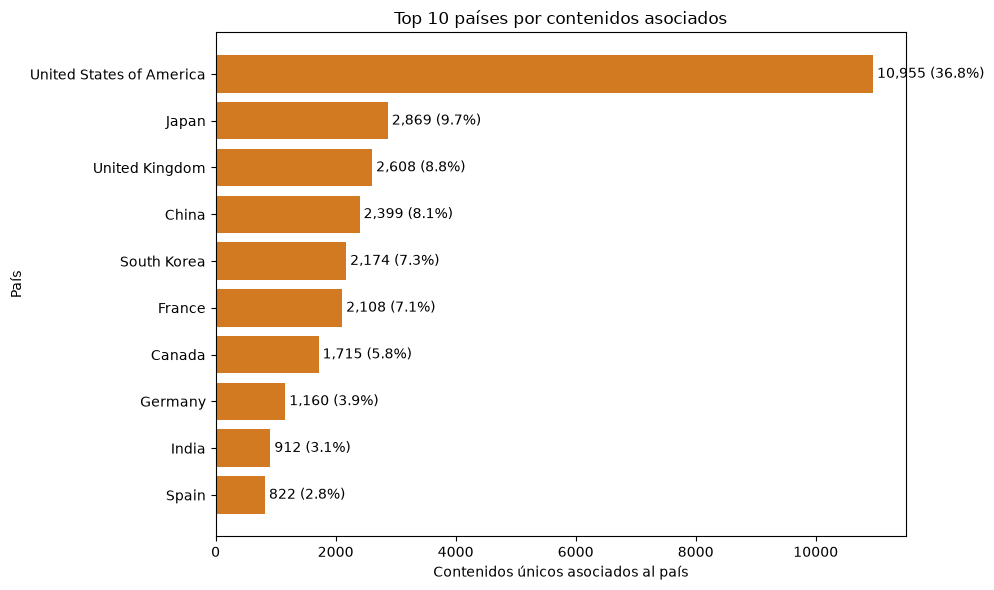

### Hallazgo

United States of America lidera el ranking con 10,955 contenidos asociados, 8,086 mas que Japan.

### Interpretación

La cobertura de country es 92.932%. Las asociaciones múltiples explican que los porcentajes de países no sean partes excluyentes del catálogo.

### Implicación

La representación geográfica observada puede orientar revisiones de diversidad de origen, comunicando siempre la cobertura parcial del campo.

In [5]:
country_denominator = catalogo_paises['content_id'].nunique()
country_top10 = catalogo_paises.groupby('country', as_index=False)['content_id'].nunique().rename(columns={'content_id': 'cantidad'})
country_top10['porcentaje'] = country_top10['cantidad'] / country_denominator * 100
country_top10 = country_top10.nlargest(10, 'cantidad').reset_index(drop=True)
display(country_top10)

plot_data = country_top10.sort_values('cantidad')
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_data['country'], plot_data['cantidad'], color='#D17A22')
ax.set_title('Top 10 países por contenidos asociados')
ax.set_xlabel('Contenidos únicos asociados al país')
ax.set_ylabel('País')
for bar, row in zip(bars, plot_data.itertuples()):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f' {row.cantidad:,} ({row.porcentaje:.1f}%)', va='center')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'paises_principales.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

country_first, country_first_count = country_top10.iloc[0][['country', 'cantidad']]
country_second, country_second_count = country_top10.iloc[1][['country', 'cantidad']]
display(Markdown(f'''### Hallazgo

{country_first} lidera el ranking con {country_first_count:,} contenidos asociados, {country_first_count - country_second_count:,} mas que {country_second}.

### Interpretación

La cobertura de country es {coverage_by_variable['country']:.3f}%. Las asociaciones múltiples explican que los porcentajes de países no sean partes excluyentes del catálogo.

### Implicación

La representación geográfica observada puede orientar revisiones de diversidad de origen, comunicando siempre la cobertura parcial del campo.'''))

## 6. Idiomas predominantes

**Pregunta de negocio:** ¿Qué idiomas predominan?

**Métrica:** contenidos únicos por código original de language.

**Visualización:** ranking horizontal de los 10 códigos con mayor presencia. Los códigos no se reemplazan para no introducir equivalencias no verificadas.

,language,cantidad,porcentaje
0,en,13969,43.665406
1,zh,2834,8.858742
2,ja,2784,8.702448
3,ko,2240,7.001969
4,es,1646,5.145197
5,fr,1639,5.123316
6,de,730,2.281892
7,hi,635,1.984933
8,tl,525,1.641087
9,pt,483,1.509800


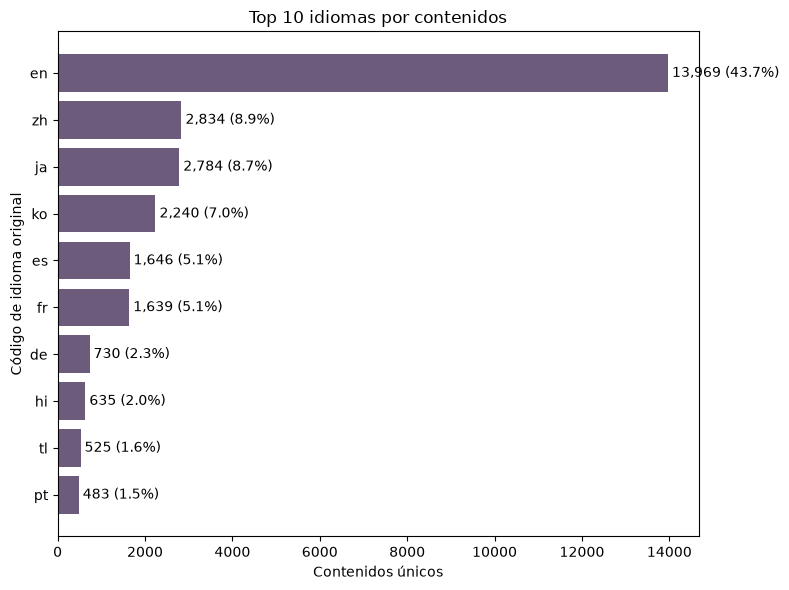

### Hallazgo

El código en aparece en 13,969 contenidos y ocupa el primer lugar; la diferencia con zh es de 11,135 contenidos.

### Interpretación

Language tiene una cobertura de 100.000% y se comporta como una variable univalor en la preparación actual.

### Implicación

La distribución permite priorizar una posterior revisión de diversidad lingüística, pero no permite concluir preferencias de audiencia.

In [6]:
language_denominator = int(catalogo_general['language'].notna().sum())
language_top10 = catalogo_general.groupby('language', as_index=False)['content_id'].nunique().rename(columns={'content_id': 'cantidad'})
language_top10['porcentaje'] = language_top10['cantidad'] / language_denominator * 100
language_top10 = language_top10.nlargest(10, 'cantidad').reset_index(drop=True)
display(language_top10)

plot_data = language_top10.sort_values('cantidad')
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(plot_data['language'], plot_data['cantidad'], color='#6C5B7B')
ax.set_title('Top 10 idiomas por contenidos')
ax.set_xlabel('Contenidos únicos')
ax.set_ylabel('Código de idioma original')
for bar, row in zip(bars, plot_data.itertuples()):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f' {row.cantidad:,} ({row.porcentaje:.1f}%)', va='center')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'idiomas_principales.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

language_first, language_first_count = language_top10.iloc[0][['language', 'cantidad']]
language_second, language_second_count = language_top10.iloc[1][['language', 'cantidad']]
display(Markdown(f'''### Hallazgo

El código {language_first} aparece en {language_first_count:,} contenidos y ocupa el primer lugar; la diferencia con {language_second} es de {language_first_count - language_second_count:,} contenidos.

### Interpretación

Language tiene una cobertura de {coverage_by_variable['language']:.3f}% y se comporta como una variable univalor en la preparación actual.

### Implicación

La distribución permite priorizar una posterior revisión de diversidad lingüística, pero no permite concluir preferencias de audiencia.'''))

## 7. Síntesis de hallazgos

La siguiente síntesis se construye con los resultados de esta ejecución.

In [7]:
display(Markdown(f'''- El catálogo contiene {len(catalogo_general):,} entidades únicas y se distribuye entre {type_summary.iloc[0]['type']} ({type_summary.iloc[0]['porcentaje']:.1f}%) y {type_summary.iloc[1]['type']} ({type_summary.iloc[1]['porcentaje']:.1f}%).
- El género con mayor presencia es {genre_top10.iloc[0]['genre']} ({genre_top10.iloc[0]['cantidad']:,} contenidos asociados).
- El país con mayor representación asociada es {country_top10.iloc[0]['country']} ({country_top10.iloc[0]['cantidad']:,}).
- El código de idioma más frecuente es {language_top10.iloc[0]['language']} ({language_top10.iloc[0]['cantidad']:,} contenidos).'''))

- El catálogo contiene 31,991 entidades únicas y se distribuye entre Movie (50.0%) y TV Show (50.0%).
- El género con mayor presencia es Drama (14,769 contenidos asociados).
- El país con mayor representación asociada es United States of America (10,955).
- El código de idioma más frecuente es en (13,969 contenidos).

## 8. Implicaciones preliminares

Estos resultados describen la oferta disponible. Pueden servir como base para conversaciones sobre equilibrio de formatos, diversidad de géneros, procedencia e idiomas, pero no prueban demanda, satisfacción ni rentabilidad.

## 9. Limitaciones

- genres y country tienen cobertura parcial; sus coberturas se reportan junto a los resultados.
- Un contenido puede tener múltiples géneros y múltiples países, por lo que los porcentajes de estas categorías pueden superar 100 % en conjunto.
- Los resultados describen composición de catálogo, no consumo de usuarios.
- popularity no se analiza en esta etapa.
- rating no permite una clasificación etaria confiable y duration no es analíticamente utilizable.

## 10. Handoff al storytelling general de EP1

Las cuatro figuras y sus tablas auditables están listas para incorporarse al storytelling conjunto de EP1. Cualquier bloque posterior que use popularity, temporalidad o finanzas debe partir de las vistas y reglas específicas ya documentadas para esas variables.